In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 200)

## Loading the Dataset

In [2]:
HealthCare_df = pd.read_csv('../data/raw/healthcare_biotech_patient_dataset.csv')
HealthCare_df.head(20)

,patient_id,age,gender,ethnicity,region,insurance_type,income_bracket,height_cm,weight_kg,bmi,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,ldl,hdl,glucose_fasting,hba1c,smoking_status,alcohol_consumption,physical_activity_level,family_history_diabetes,family_history_heart_disease,white_blood_cell_count,red_blood_cell_count,platelet_count,crp_level,vitamin_d_level,gene_marker_score,biomarker_a,biomarker_b,num_chronic_conditions,num_prior_hospital_visits,medication_count,admission_type,department,treatment_type,had_surgery,length_of_stay_days,admission_date,discharge_date,readmitted_30days,total_healthcare_cost
0,158790,39.9,f,NaN,West,MEDICARE,NaN,152.8,90.3,NaN,133.0,70.0,80.0,212.0,106.0,59.0,125.0,7.2,Never,Moderate,Light,0,0,NaN,3.20,190.0,2.79,NaN,32.92,1.70,38.11,1,2,1.0,Emergency,Emergency,Medication,0,3,2022-01-24,2022-01-27,1,2778.44
1,314295,17.7,M,NaN,Northeast,medicare,100k-150k,172.9,88.3,29.5,114.0,71.0,66.0,219.0,131.0,68.0,98.0,NaN,NaN,NaN,Sedentary,1,0,NaN,5.11,281.0,8.84,27.0,29.68,NaN,NaN,0,1,0.0,Elective,Orthopedics,Combination,0,2,2022-02-20,2022-02-22,0,2102.12
2,173610,55.5,FEMALE,Hispanic,South,PRIVATE,25k-50k,173.0,69.0,23.1,113.0,65.0,66.0,193.0,112.0,75.0,112.0,7.2,Current,NaN,Moderate,1,0,7.61,5.76,295.0,NaN,35.9,31.48,NaN,NaN,0,2,2.0,Newborn,Pediatrics,Medication,0,0,2023-10-14,2023-10-14,0,1452.31
3,296884,32.4,Male,Hispanic,Northeast,NaN,50k-75k,173.8,95.3,31.5,118.0,64.0,70.0,210.0,NaN,NaN,95.0,6.4,Never,Heavy,Light,0,0,7.12,4.97,286.0,NaN,NaN,21.80,5.33,54.51,1,0,1.0,Emergency,Emergency,Therapy,0,0,2022-12-11,2022-12-11,0,2005.37
4,324447,81.0,F,Black,Northeast,medicare,NaN,158.6,92.5,36.8,124.0,77.0,75.0,NaN,162.0,51.0,120.0,7.4,Never,NaN,Sedentary,1,0,NaN,NaN,185.0,1.99,27.1,40.84,NaN,45.67,2,5,1.0,Elective,Endocrinology,Observation,0,2,2021-01-26,2021-01-28,0,3840.04
5,223935,49.5,MALE,Unknown,Midwest,private,25k-50k,182.9,78.4,23.4,138.0,78.0,74.0,208.0,119.0,67.0,103.0,6.6,Former,Light,Active,0,1,7.83,4.35,276.0,11.84,11.1,43.75,1.36,58.40,0,2,0.0,Emergency,General Medicine,Medication,0,4,2020-05-06,2020-05-10,1,2207.07
6,332159,52.3,F,White,Midwest,uninsured,25k-50k,166.9,64.6,23.2,126.0,71.0,76.0,246.0,NaN,66.0,112.0,6.2,Former,Light,Moderate,0,1,7.69,3.35,287.0,8.36,39.3,41.02,7.02,NaN,0,1,0.0,Emergency,Oncology,Therapy,0,1,2020-02-09,2020-02-10,0,1805.02
7,14143,6.9,F,Black,Midwest,Medicaid,100k-150k,172.8,71.2,23.8,111.0,77.0,83.0,215.0,140.0,NaN,104.0,5.5,never,Light,Light,0,1,8.27,4.55,175.0,6.50,NaN,19.73,2.39,NaN,0,0,0.0,Urgent,Oncology,Medication,0,2,2020-08-20,2020-08-22,0,2217.61
8,26611,22.0,female,Asian,Northeast,Medicare,25k-50k,163.1,67.8,25.5,114.0,61.0,84.0,243.0,129.0,NaN,112.0,6.4,Former,Light,Light,1,0,8.12,5.78,158.0,7.36,NaN,48.13,5.47,NaN,1,4,0.0,Emergency,Emergency,Medication,0,0,2022-01-30,2022-01-30,0,2205.64
9,115623,42.5,F,Asian,Northeast,NaN,NaN,171.6,96.9,32.9,134.0,90.0,82.0,275.0,NaN,54.0,134.0,6.5,Never,Light,Moderate,0,0,5.45,4.46,293.0,8.46,NaN,53.93,1.67,51.03,2,6,0.0,Emergency,Oncology,Surgery,1,3,2023-11-21,2023-11-24,1,5191.19


## Understanding the Dataset

In [3]:
HealthCare_df.shape

(403650, 43)

In [4]:
HealthCare_df.columns

Index(['patient_id', 'age', 'gender', 'ethnicity', 'region', 'insurance_type',
       'income_bracket', 'height_cm', 'weight_kg', 'bmi', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'ldl', 'hdl',
       'glucose_fasting', 'hba1c', 'smoking_status', 'alcohol_consumption',
       'physical_activity_level', 'family_history_diabetes',
       'family_history_heart_disease', 'white_blood_cell_count',
       'red_blood_cell_count', 'platelet_count', 'crp_level',
       'vitamin_d_level', 'gene_marker_score', 'biomarker_a', 'biomarker_b',
       'num_chronic_conditions', 'num_prior_hospital_visits',
       'medication_count', 'admission_type', 'department', 'treatment_type',
       'had_surgery', 'length_of_stay_days', 'admission_date',
       'discharge_date', 'readmitted_30days', 'total_healthcare_cost'],
      dtype='object')

In [5]:
HealthCare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403650 entries, 0 to 403649
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   patient_id                    403650 non-null  int64  
 1   age                           403650 non-null  float64
 2   gender                        399640 non-null  object 
 3   ethnicity                     383386 non-null  object 
 4   region                        403650 non-null  object 
 5   insurance_type                375814 non-null  object 
 6   income_bracket                343175 non-null  object 
 7   height_cm                     379347 non-null  float64
 8   weight_kg                     379464 non-null  float64
 9   bmi                           387497 non-null  float64
 10  systolic_bp                   383763 non-null  float64
 11  diastolic_bp                  383615 non-null  float64
 12  heart_rate                    403650 non-nul

In [6]:
HealthCare_df.describe()

,patient_id,age,height_cm,weight_kg,bmi,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,ldl,hdl,glucose_fasting,hba1c,family_history_diabetes,family_history_heart_disease,white_blood_cell_count,red_blood_cell_count,platelet_count,crp_level,vitamin_d_level,gene_marker_score,biomarker_a,biomarker_b,num_chronic_conditions,num_prior_hospital_visits,medication_count,had_surgery,length_of_stay_days,readmitted_30days,total_healthcare_cost
count,403650.000000,403650.000000,379347.00000,379464.000000,387497.000000,383763.000000,383615.000000,403650.000000,362940.000000,342832.000000,342805.000000,371035.000000,323299.000000,403650.000000,403650.000000,355195.000000,355429.000000,355215.000000,331200.000000,303007.000000,403650.000000,282246.000000,282249.000000,403650.000000,403650.000000,383475.000000,403650.000000,403650.000000,403650.000000,403650.000000
mean,194986.523221,52.684268,169.24563,78.329253,27.482232,128.176739,76.249586,76.039225,209.507751,125.705716,55.885390,104.656186,6.255557,0.300394,0.320017,6.994696,4.799998,249.901209,4.929943,27.993915,41.519441,5.368250,49.952458,1.229454,3.216574,1.134627,0.212310,3.332640,0.379881,3771.062044
std,112574.346930,30.148060,9.53958,19.039266,7.388200,15.338851,9.257830,13.725240,27.291585,22.217519,10.044436,15.346579,0.440558,0.458430,0.466483,2.002314,0.599989,59.914265,3.290417,10.002617,12.011240,3.521646,14.992158,1.183120,2.164535,1.255640,0.408944,15.919967,0.485358,24015.832602
min,1.000000,-5.000000,132.40000,30.000000,0.000000,60.000000,32.000000,-24.000000,91.000000,14.000000,12.000000,37.000000,4.200000,0.000000,0.000000,-2.110000,2.270000,-60.000000,0.000000,-23.000000,0.000000,0.300000,-14.900000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-500.000000
25%,97488.250000,39.900000,162.30000,65.400000,22.800000,118.000000,70.000000,68.000000,191.000000,111.000000,49.000000,94.000000,6.000000,0.000000,0.000000,5.640000,4.390000,210.000000,2.260000,21.300000,33.370000,2.990000,39.840000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,2263.572500
50%,194994.500000,52.000000,169.20000,78.300000,27.200000,128.000000,76.000000,76.000000,210.000000,126.000000,56.000000,105.000000,6.300000,0.000000,0.000000,7.000000,4.800000,250.000000,4.510000,28.000000,41.470000,4.490000,49.980000,1.000000,3.000000,1.000000,0.000000,3.000000,0.000000,2915.970000
75%,292464.750000,64.200000,176.20000,91.200000,31.800000,139.000000,83.000000,84.000000,228.000000,141.000000,63.000000,115.000000,6.600000,1.000000,1.000000,8.340000,5.200000,290.000000,7.100000,34.800000,49.600000,6.720000,60.050000,2.000000,4.000000,2.000000,0.000000,4.000000,1.000000,3716.725000
max,390000.000000,999.000000,208.40000,169.200000,120.000000,199.000000,120.000000,303.000000,340.000000,230.000000,99.000000,177.000000,8.200000,1.000000,1.000000,15.630000,7.500000,528.000000,23.190000,74.300000,96.240000,67.860000,116.670000,11.000000,18.000000,12.000000,1.000000,500.000000,1.000000,999999.000000


In [7]:
HealthCare_df.isnull().sum()

patient_id                           0
age                                  0
gender                            4010
ethnicity                        20264
region                               0
insurance_type                   27836
income_bracket                   60475
height_cm                        24303
weight_kg                        24186
bmi                              16153
systolic_bp                      19887
diastolic_bp                     20035
heart_rate                           0
cholesterol_total                40710
ldl                              60818
hdl                              60845
glucose_fasting                  32615
hba1c                            80351
smoking_status                   28137
alcohol_consumption             164684
physical_activity_level          40456
family_history_diabetes              0
family_history_heart_disease         0
white_blood_cell_count           48455
red_blood_cell_count             48221
platelet_count           

In [8]:
HealthCare_df.duplicated().sum()

10515

In [9]:
HealthCare_df[HealthCare_df.duplicated(keep=False)]

,patient_id,age,gender,ethnicity,region,insurance_type,income_bracket,height_cm,weight_kg,bmi,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,ldl,hdl,glucose_fasting,hba1c,smoking_status,alcohol_consumption,physical_activity_level,family_history_diabetes,family_history_heart_disease,white_blood_cell_count,red_blood_cell_count,platelet_count,crp_level,vitamin_d_level,gene_marker_score,biomarker_a,biomarker_b,num_chronic_conditions,num_prior_hospital_visits,medication_count,admission_type,department,treatment_type,had_surgery,length_of_stay_days,admission_date,discharge_date,readmitted_30days,total_healthcare_cost
16,109629,40.7,MALE,Black,West,uninsured,25k-50k,NaN,59.7,21.7,135.0,73.0,67.0,250.0,169.0,68.0,87.0,5.4,Former,Light,Active,0,1,8.66,5.33,229.0,9.48,NaN,53.54,6.09,64.25,1,2,2.0,Urgent,Neurology,Surgery,1,4,2022-01-29,2022-02-02,1,3491.71
35,362654,64.1,O,Native American,Midwest,private,50k-75k,166.3,NaN,18.8,115.0,NaN,74.0,260.0,162.0,44.0,110.0,5.9,Never,Light,Moderate,0,0,NaN,4.60,214.0,7.96,NaN,57.64,6.70,NaN,1,2,1.0,Emergency,Orthopedics,Surgery,1,2,2023-05-27,2023-05-29,0,5641.70
73,275250,78.4,Male,White,Northeast,medicaid,>150k,184.8,NaN,16.2,135.0,82.0,90.0,222.0,154.0,60.0,98.0,6.1,Former,Light,Moderate,1,0,6.23,5.06,257.0,2.31,46.3,53.09,4.09,44.87,1,2,0.0,Urgent,Orthopedics,Combination,0,6,2022-05-11,2022-05-17,0,4579.25
89,196745,44.4,male,Black,South,Priv.,100k-150k,176.4,64.1,20.6,125.0,79.0,55.0,249.0,NaN,41.0,92.0,6.0,Current,Light,Active,1,1,7.25,4.90,NaN,NaN,25.5,40.50,2.72,75.47,1,5,0.0,Emergency,General Medicine,Medication,1,8,2022-05-17,2022-05-25,1,1159.93
103,163712,60.0,Male,Black,Northeast,MEDICARE,25k-50k,172.8,102.5,34.3,139.0,70.0,62.0,234.0,112.0,77.0,93.0,5.4,NaN,Moderate,Light,0,0,NaN,4.11,211.0,0.86,20.0,24.45,NaN,56.10,0,4,1.0,Elective,Orthopedics,Medication,0,0,2022-08-16,2022-08-16,0,2199.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403535,124376,14.4,f,Hispanic,Northeast,PRIVATE,>150k,158.2,32.8,13.1,138.0,56.0,59.0,157.0,96.0,64.0,108.0,6.1,Former,NaN,Sedentary,0,0,2.52,NaN,182.0,NaN,27.9,28.84,3.25,NaN,0,0,1.0,Urgent,Emergency,Medication,0,1,2020-10-31,2020-11-01,0,1722.51
403568,315140,32.6,MALE,White,Midwest,PRIVATE,>150k,175.1,53.6,17.5,117.0,73.0,68.0,179.0,119.0,72.0,107.0,6.4,Former,NaN,Sedentary,1,1,3.39,4.39,230.0,7.21,25.6,56.07,7.06,NaN,1,3,1.0,Emergency,Endocrinology,Therapy,0,5,2024-02-06,2024-02-11,1,2861.67
403590,205042,90.6,female,Asian,Northeast,Priv.,NaN,170.8,49.1,16.8,129.0,70.0,85.0,223.0,112.0,66.0,97.0,6.5,current,Light,Active,1,0,3.23,NaN,260.0,NaN,29.9,63.48,5.13,NaN,0,3,0.0,Elective,Emergency,Surgery,1,2,2024-04-06,2024-04-08,1,3544.11
403617,260280,80.9,Male,White,Midwest,PRIVATE,100k-150k,182.9,90.5,27.1,149.0,73.0,71.0,289.0,180.0,51.0,82.0,5.9,Never,NaN,Light,0,0,6.02,NaN,292.0,5.67,NaN,51.79,NaN,NaN,1,5,2.0,Elective,Emergency,Observation,0,4,2023-02-24,2023-02-28,0,1555.94


In [10]:
for column in HealthCare_df.columns :
    print(f'...Describing Column {column}...:')
    print(HealthCare_df[column].describe())
    print('\n')

...Describing Column patient_id...:
count    403650.000000
mean     194986.523221
std      112574.346930
min           1.000000
25%       97488.250000
50%      194994.500000
75%      292464.750000
max      390000.000000
Name: patient_id, dtype: float64


...Describing Column age...:
count    403650.000000
mean         52.684268
std          30.148060
min          -5.000000
25%          39.900000
50%          52.000000
75%          64.200000
max         999.000000
Name: age, dtype: float64


...Describing Column gender...:
count     399640
unique        14
top            F
freq       39314
Name: gender, dtype: object


...Describing Column ethnicity...:
count     383386
unique        28
top        White
freq      148602
Name: ethnicity, dtype: object


...Describing Column region...:
count     403650
unique         4
top        South
freq      129240
Name: region, dtype: object


...Describing Column insurance_type...:
count      375814
unique         14
top       Private
freq        44

In [11]:
columns = ['gender', 'ethnicity', 'region', 'insurance_type',
       'income_bracket', 'smoking_status', 'alcohol_consumption',
       'physical_activity_level', 'num_chronic_conditions', 'num_prior_hospital_visits',
       'medication_count', 'admission_type', 'department', 'treatment_type', 'length_of_stay_days'] 
for column in HealthCare_df.columns :
    if column in columns :
        print(f'...Value_Counts in {column}...: ')
        print(HealthCare_df[column].value_counts())
        print('\n')

...Value_Counts in gender...: 
gender
F             39314
female        39223
f             39124
Female        39030
FEMALE        38977
male          38517
M             38496
m             38384
Male          38337
MALE          38267
Other          3063
O              3032
other          2961
Non-binary     2915
Name: count, dtype: int64


...Value_Counts in ethnicity...: 
ethnicity
White                  148602
Hispanic                74399
Black                   67261
Asian                   44590
Other                   14900
Native American         11141
Unknown                 10995
white                    1586
WHITE                    1534
  White                  1504
  Hispanic                807
HISPANIC                  788
hispanic                  711
  Black                   710
BLACK                     689
black                     670
  Asian                   486
ASIAN                     463
asian                     432
other                     176
OTHER     

<Axes: >

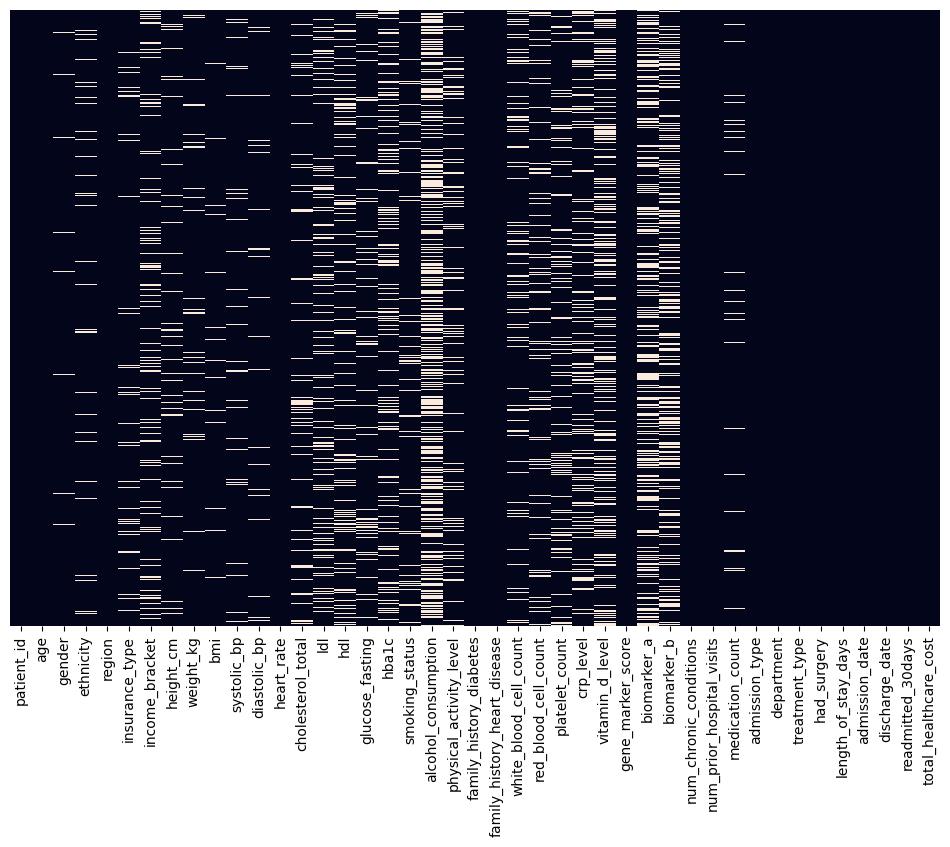

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(HealthCare_df.isnull(), cbar=False, yticklabels=False)